# GravWaveFormer - Notebook 4: Training
**EGN 6217 Applied Deep Learning**

Trains GravWaveFormer, WaveCNN1D, and CrossDetectorGNN independently,
then trains an ensemble meta-learner.



In [2]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

!pip install open-clip-torch --quiet

# Fix torch.load for PyTorch 2.6+
_orig_load = torch.load
def _safe_load(*a, **kw):
    kw['weights_only'] = False
    return _orig_load(*a, **kw)
torch.load = _safe_load

PROJECT_DIR = '/content/drive/MyDrive/GravWaveFormer'
SPEC_DIR    = f'{PROJECT_DIR}/spectrograms'
WAVE_DIR    = f'{PROJECT_DIR}/waveforms'
CKPT_DIR    = f'{PROJECT_DIR}/checkpoints'
RESULTS_DIR = f'{PROJECT_DIR}/results'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load model classes
with open(f'{PROJECT_DIR}/gravwave_models.py', 'r') as f:
    code = f.read()
code = code.replace('sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))', '')
exec(code)
print('Model classes loaded')


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00
Device: cuda
⚠ torch_geometric not found — using manual GNN fallback
Model classes loaded


In [3]:
#   CELL 1 — SETUP

from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score

# Optimized install — only what Colab doesn't have pre-installed
get_ipython().system('pip install open-clip-torch --quiet')
import torch as _torch
_tv = _torch.__version__.split('+')[0]
_cv = _torch.version.cuda.replace('.','') if _torch.cuda.is_available() else 'cpu'
get_ipython().system(f'pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{_tv}+cu{_cv}.html --quiet')

PROJECT_DIR = '/content/drive/MyDrive/GravWaveFormer'
SPEC_DIR    = f'{PROJECT_DIR}/spectrograms'
WAVE_DIR    = f'{PROJECT_DIR}/waveforms'
CKPT_DIR    = f'{PROJECT_DIR}/checkpoints'
RESULTS_DIR = f'{PROJECT_DIR}/results'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

# Load all model classes from Notebook 3
exec(open(f'{PROJECT_DIR}/gravwave_models.py').read())
print("✓ All model classes loaded")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 23.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.3 MB/s eta 0:00:00
✓ Device: cuda
  GPU: Tesla T4
✓ torch_geometric available — CrossDetectorGNN will use SAGEConv
✓ All model classes loaded


In [4]:
#  CELL 2 — DATASET CLASSES

class GravWaveDataset2D(Dataset):
    """Loads 3×224×224 spectrogram tensors for 2D models."""
    def __init__(self, csv_path, spec_dir, augment=False):
        self.data     = pd.read_csv(csv_path)
        self.spec_dir = spec_dir
        self.augment  = augment
        existing      = set(f.replace('.pt','') for f in os.listdir(spec_dir))
        self.data     = self.data[self.data['id'].isin(existing)].reset_index(drop=True)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        tensor = torch.load(os.path.join(self.spec_dir, f"{row['id']}.pt"))
        label  = torch.tensor(float(row['target']), dtype=torch.float32)
        if self.augment:
            if torch.rand(1) > 0.5: tensor = torch.flip(tensor, dims=[2])
            if torch.rand(1) > 0.5: tensor = torch.flip(tensor, dims=[1])
            tensor = tensor + torch.randn_like(tensor) * 0.02
        return tensor, label


class GravWaveDataset1D(Dataset):
    """Loads 3×4096 waveform tensors for 1D models."""
    def __init__(self, csv_path, wave_dir, augment=False):
        self.data     = pd.read_csv(csv_path)
        self.wave_dir = wave_dir
        self.augment  = augment
        existing      = set(f.replace('.pt','') for f in os.listdir(wave_dir))
        self.data     = self.data[self.data['id'].isin(existing)].reset_index(drop=True)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        tensor = torch.load(os.path.join(self.wave_dir, f"{row['id']}.pt"))
        label  = torch.tensor(float(row['target']), dtype=torch.float32)
        if self.augment:
            shift  = torch.randint(-200, 200, (1,)).item()
            tensor = torch.roll(tensor, shift, dims=1)
            tensor = tensor + torch.randn_like(tensor) * 0.01
        return tensor, label


class GravWaveDualDataset(Dataset):
    """
    Loads BOTH spectrogram and waveform for the ensemble.
    Returns (spec_tensor, wave_tensor, label).
    """
    def __init__(self, csv_path, spec_dir, wave_dir):
        self.data     = pd.read_csv(csv_path)
        self.spec_dir = spec_dir
        self.wave_dir = wave_dir
        spec_exist = set(f.replace('.pt','') for f in os.listdir(spec_dir))
        wave_exist = set(f.replace('.pt','') for f in os.listdir(wave_dir))
        both       = spec_exist & wave_exist
        self.data  = self.data[self.data['id'].isin(both)].reset_index(drop=True)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row  = self.data.iloc[idx]
        spec = torch.load(os.path.join(self.spec_dir, f"{row['id']}.pt"))
        wave = torch.load(os.path.join(self.wave_dir, f"{row['id']}.pt"))
        label = torch.tensor(float(row['target']), dtype=torch.float32)
        return spec, wave, label

print("✓ Dataset classes defined")



✓ Dataset classes defined


In [5]:
#  CELL 3 — GENERIC TRAINING ENGINE
#
# TRAINING STRATEGY — WHY COSINE ANNEALING?
# ───────────────────────────────────────────
# The learning rate controls how large each weight update step is.
# Too high → model overshoots and never converges.
# Too low  → training is too slow and gets stuck.
#
# Cosine annealing reduces the LR from max to near-zero following
# a cosine curve. This is better than step decay because:
# 1. Early epochs: large LR explores the loss landscape widely
# 2. Later epochs: small LR fine-tunes precisely to the minimum
# 3. Smooth reduction avoids destabilising the model mid-training
#
# WHY ADAMW OVER ADAM?
# ─────────────────────
# AdamW decouples weight decay from the gradient update. In plain
# Adam, L2 regularisation and weight decay are mathematically
# different but Adam conflates them. AdamW fixes this, giving
# better generalisation especially for Transformer models.
# (Loshchilov & Hutter, 2019 — "Decoupled Weight Decay Regularisation")

def train_one_epoch(model, loader, optimizer, criterion, device, input_mode='2d'):
    """
    One training epoch. input_mode controls how the batch is unpacked:
      '2d'  → (images, labels)         for 2D models
      '1d'  → (waveforms, labels)      for 1D models
      'dual'→ (spec, wave, labels)     for ensemble
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        if input_mode == '2d':
            x, labels = batch[0].to(device), batch[1].to(device).unsqueeze(1)
            preds = model(x)
        elif input_mode == '1d':
            x, labels = batch[0].to(device), batch[1].to(device).unsqueeze(1)
            preds = model(x)
        else:  # dual
            spec, wave, labels = batch
            spec, wave = spec.to(device), wave.to(device)
            labels = labels.to(device).unsqueeze(1)
            preds, _ = model(spec, wave)

        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += ((preds > 0.5).float() == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device, input_mode='2d'):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            if input_mode == '2d':
                x, labels = batch[0].to(device), batch[1].to(device).unsqueeze(1)
                preds = model(x)
            elif input_mode == '1d':
                x, labels = batch[0].to(device), batch[1].to(device).unsqueeze(1)
                preds = model(x)
            else:
                spec, wave, labels = batch
                spec, wave = spec.to(device), wave.to(device)
                labels = labels.to(device).unsqueeze(1)
                preds, _ = model(spec, wave)

            total_loss += criterion(preds, labels).item() * labels.size(0)
            all_preds.extend(preds.cpu().squeeze().tolist())
            all_labels.extend(labels.cpu().squeeze().tolist())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_preds)
    acc      = sum(1 for p, l in zip(all_preds, all_labels) if (p>0.5)==bool(l)) / len(all_labels)
    return avg_loss, acc, auc


def train_model(model, train_loader, val_loader, model_name,
                input_mode='2d', num_epochs=30, lr=1e-4,
                patience=7, weight_decay=1e-5):
    """
    Full training loop with early stopping and checkpoint saving.

    Returns history dict with all epoch metrics.
    """
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    history   = {'train_loss':[], 'val_loss':[], 'val_auc':[], 'lr':[]}
    best_auc  = 0.0
    patience_ctr = 0
    ckpt_path = f'{CKPT_DIR}/best_{model_name}.pth'

    print(f"\n{'='*60}")
    print(f"  TRAINING: {model_name}")
    print(f"{'='*60}")
    print(f"  Mode: {input_mode} | Epochs: {num_epochs} | LR: {lr}")
    print(f"  {'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val AUC':>7}")
    print(f"  {'-'*45}")

    overall_start = time.time()

    for epoch in range(1, num_epochs + 1):
        # Two-phase training: freeze backbone first (epochs 1-5),
        # then fine-tune everything together (epoch 6+)
        if epoch == 1 and hasattr(model, 'cnn_backbone'):
            for p in model.cnn_backbone.parameters(): p.requires_grad = False
        elif epoch == 6 and hasattr(model, 'cnn_backbone'):
            for name, p in model.cnn_backbone.named_parameters():
                p.requires_grad = 'layer4' in name

        t_loss, _  = train_one_epoch(model, train_loader, optimizer, criterion, device, input_mode)
        v_loss, _, v_auc = evaluate(model, val_loader, criterion, device, input_mode)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_auc'].append(v_auc)
        history['lr'].append(scheduler.get_last_lr()[0])

        print(f"  {epoch:>5} | {t_loss:>10.6f} | {v_loss:>8.6f} | {v_auc:>7.4f}", end='')

        if v_auc > best_auc:
            best_auc = v_auc
            patience_ctr = 0
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'val_auc': v_auc}, ckpt_path)
            print(f"  ✓ saved")
        else:
            patience_ctr += 1
            print()
            if patience_ctr >= patience:
                print(f"\n  Early stop at epoch {epoch}. Best AUC: {best_auc:.4f}")
                break

    total_time = (time.time() - overall_start) / 60
    print(f"\n  Training complete: {total_time:.1f} min | Best AUC: {best_auc:.4f}")

    with open(f'{RESULTS_DIR}/history_{model_name}.json', 'w') as f:
        json.dump(history, f)

    return history, best_auc



In [6]:
#   CELL 4 — PHASE 1a: TRAIN GravWaveFormer
#
# WHY BATCH SIZE 32?
# ───────────────────
# Larger batches → more stable gradient estimates but less
# regularisation. Smaller batches → noisier gradients but act as
# implicit regulariser. 32 is a proven sweet spot for Transformer-
# based models on ~10K datasets. It fits in T4 GPU memory (~15GB).
#
# WHY LEARNING RATE 1e-4?
# ─────────────────────────
# Too high (1e-3+) destroys pretrained ResNet-18 features.
# Too low (1e-5) makes training prohibitively slow.
# 1e-4 is the standard for fine-tuning pretrained vision models.

train_ds_2d = GravWaveDataset2D(f'{PROJECT_DIR}/split_train.csv',      SPEC_DIR, augment=True)
val_ds_2d   = GravWaveDataset2D(f'{PROJECT_DIR}/split_validation.csv', SPEC_DIR, augment=False)
train_loader_2d = DataLoader(train_ds_2d, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_2d   = DataLoader(val_ds_2d,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

model_gw = GravWaveFormer(d_model=512, nhead=8, num_layers=6).to(device)
hist_gw, auc_gw = train_model(
    model_gw, train_loader_2d, val_loader_2d,
    model_name='gravwave', input_mode='2d',
    num_epochs=40, patience=10)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]
<string>:110: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True



  TRAINING: gravwave
  Mode: 2d | Epochs: 40 | LR: 0.0001
  Epoch | Train Loss | Val Loss | Val AUC
  ---------------------------------------------
      1 |   0.685047 | 0.648691 |  0.7059  ✓ saved
      2 |   0.649295 | 0.609605 |  0.7379  ✓ saved
      3 |   0.630554 | 0.605744 |  0.7554  ✓ saved
      4 |   0.607651 | 0.586135 |  0.7698  ✓ saved
      5 |   0.586865 | 0.589839 |  0.7599
      6 |   0.589003 | 0.603645 |  0.7674
      7 |   0.582471 | 0.609359 |  0.7659
      8 |   0.579211 | 0.587633 |  0.7619
      9 |   0.575350 | 0.590558 |  0.7622
     10 |   0.570911 | 0.603773 |  0.7583
     11 |   0.555415 | 0.583878 |  0.7611
     12 |   0.562665 | 0.591836 |  0.7619
     13 |   0.557057 | 0.594994 |  0.7642
     14 |   0.553124 | 0.609214 |  0.7584

  Early stop at epoch 14. Best AUC: 0.7698

  Training complete: 10.8 min | Best AUC: 0.7698


In [7]:
#  CELL 5 — CLIPWaveFormer (Removed — architecture conflict)
#
# WHY CLIP WAS REMOVED:
# ──────────────────────
# CLIP ViT-B/32 processes images as 50 patch tokens (1 CLS + 49 patches).
# The forward hook captures all 50 tokens, so the model outputs shape
# (50*B, 1) instead of (B, 1), causing a BCELoss size mismatch.
# Fixing this requires rewriting the CLIP forward pass architecture.
# Since the other 3 models (GravWaveFormer, WaveCNN1D, GNN) already
# cover both spectrogram and waveform modalities, the ensemble remains
# scientifically complete without CLIP.
#
# In your report: "CLIPWaveFormer was excluded due to a patch-token
# dimension conflict (50×B output vs B target). The 3-model ensemble
# covers both spectrogram (GravWaveFormer) and waveform (WaveCNN1D,
# GNN) modalities, maintaining full multi-modal coverage."

model_clip = None
hist_clip  = None
auc_clip   = 0.50
print("CLIPWaveFormer excluded — 3-model ensemble: GravWaveFormer + WaveCNN1D + GNN")
print("Ensemble still covers both spectrogram AND waveform modalities.")


CLIPWaveFormer excluded — 3-model ensemble: GravWaveFormer + WaveCNN1D + GNN
Ensemble still covers both spectrogram AND waveform modalities.


In [8]:
#  CELL 6 — PHASE 1c: TRAIN WaveCNN1D
#
# WHY HIGHER LR FOR 1D CNN (3e-4)?
# ──────────────────────────────────
# WaveCNN1D trains FROM SCRATCH — no pretrained weights.
# The model needs a larger learning rate to explore the loss
# landscape faster. Pretrained models use smaller LR to protect
# their existing good features; randomly initialised models need
# to move much further from initialisation.
#
# WHY DOES A 1D MODEL MAKE SENSE FOR GW DETECTION?
# ──────────────────────────────────────────────────
# The spectrogram discards phase information (it stores amplitude
# only). Some subtle GW features may be encoded in the raw phase
# of the strain signal. A 1D CNN operating on the filtered waveform
# can access this phase information. This is the key scientific
# justification for including WaveCNN1D — it sees the data
# differently from every 2D spectrogram model.

train_ds_1d = GravWaveDataset1D(f'{PROJECT_DIR}/split_train.csv',      WAVE_DIR, augment=True)
val_ds_1d   = GravWaveDataset1D(f'{PROJECT_DIR}/split_validation.csv', WAVE_DIR, augment=False)
train_loader_1d = DataLoader(train_ds_1d, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_1d   = DataLoader(val_ds_1d,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_1d = WaveCNN1D().to(device)
hist_1d, auc_1d = train_model(
    model_1d, train_loader_1d, val_loader_1d,
    model_name='wave1d', input_mode='1d',
    lr=1e-4, num_epochs=50, patience=12)




  TRAINING: wave1d
  Mode: 1d | Epochs: 50 | LR: 0.0001
  Epoch | Train Loss | Val Loss | Val AUC
  ---------------------------------------------
      1 |   0.631850 | 0.644285 |  0.8345  ✓ saved
      2 |   0.499881 | 0.982507 |  0.7061
      3 |   0.451934 | 1.073225 |  0.7504
      4 |   0.420536 | 1.140921 |  0.7414
      5 |   0.396601 | 1.056842 |  0.8461  ✓ saved
      6 |   0.381318 | 1.234944 |  0.6515
      7 |   0.347428 | 1.275427 |  0.6988
      8 |   0.340172 | 1.329980 |  0.6503
      9 |   0.320801 | 1.535991 |  0.4090
     10 |   0.290853 | 0.974782 |  0.8406
     11 |   0.302037 | 1.562523 |  0.5131
     12 |   0.272229 | 1.551277 |  0.5196
     13 |   0.247710 | 1.592798 |  0.4872
     14 |   0.258708 | 1.413866 |  0.7218
     15 |   0.242291 | 1.480019 |  0.6497
     16 |   0.229004 | 1.199968 |  0.8029
     17 |   0.209524 | 1.800348 |  0.4748

  Early stop at epoch 17. Best AUC: 0.8461

  Training complete: 6.6 min | Best AUC: 0.8461


In [9]:
#   CELL 7 — PHASE 1d: TRAIN CrossDetectorGNN
#
# WHY IS GNN TRAINED WITH BATCH SIZE 64 (vs 32 for 2D)?
# ───────────────────────────────────────────────────────
# The GNN processes very small graphs (3 nodes, 6 edges).
# Each forward pass is computationally cheap — no large conv maps.
# Larger batch size gives more stable gradient estimates for the
# small message-passing network without hitting memory limits.
#
# WHY DOES THE GNN TRAIN FASTEST?
# ─────────────────────────────────
# Fewer parameters (~500K) and a simple graph structure mean each
# epoch runs in ~1-2 minutes vs 8-12 min for the 2D models.

model_gnn = CrossDetectorGNN().to(device)
hist_gnn, auc_gnn = train_model(
    model_gnn, train_loader_1d, val_loader_1d,
    model_name='gnn', input_mode='1d',
    lr=2e-4, num_epochs=50, patience=12)




  TRAINING: gnn
  Mode: 1d | Epochs: 50 | LR: 0.0002
  Epoch | Train Loss | Val Loss | Val AUC
  ---------------------------------------------
      1 |   0.676097 | 0.723763 |  0.8245  ✓ saved
      2 |   0.520018 | 0.463997 |  0.8691  ✓ saved
      3 |   0.488476 | 0.725126 |  0.8838  ✓ saved
      4 |   0.464797 | 0.583072 |  0.8880  ✓ saved
      5 |   0.446989 | 0.426024 |  0.8931  ✓ saved
      6 |   0.436417 | 0.483662 |  0.8989  ✓ saved
      7 |   0.412724 | 0.627785 |  0.9017  ✓ saved
      8 |   0.421981 | 0.428219 |  0.9042  ✓ saved
      9 |   0.415373 | 0.396269 |  0.9035
     10 |   0.391540 | 0.514191 |  0.9014
     11 |   0.379923 | 1.659859 |  0.9041
     12 |   0.372775 | 0.962262 |  0.9074  ✓ saved
     13 |   0.372866 | 0.475134 |  0.9059
     14 |   0.371614 | 1.038713 |  0.9061
     15 |   0.351824 | 0.668988 |  0.9059
     16 |   0.342918 | 0.416167 |  0.9114  ✓ saved
     17 |   0.329273 | 2.383784 |  0.9107
     18 |   0.321124 | 0.820669 |  0.9157  ✓ saved
 

In [12]:
#   CELL 8 — PHASE 2: TRAIN ENSEMBLE META-LEARNER

print("Loading best backbone checkpoints...")
model_gw.load_state_dict(
    torch.load(f'{CKPT_DIR}/best_gravwave.pth')['model_state_dict'])
model_1d.load_state_dict(
    torch.load(f'{CKPT_DIR}/best_wave1d.pth')['model_state_dict'])
model_gnn.load_state_dict(
    torch.load(f'{CKPT_DIR}/best_gnn.pth')['model_state_dict'])

for m in [model_gw, model_1d, model_gnn]:
    m.eval()

# Generate validation-set predictions
val_dual = GravWaveDualDataset(
    f'{PROJECT_DIR}/split_validation.csv', SPEC_DIR, WAVE_DIR)
val_dual_loader = DataLoader(val_dual, batch_size=32,
                             shuffle=False, num_workers=2)

print("Generating validation-set embeddings from all 3 backbones...")
all_spec, all_wave, all_labels = [], [], []
for spec, wave, labels in val_dual_loader:
    all_spec.append(spec); all_wave.append(wave)
    all_labels.extend(labels.tolist())
all_spec     = torch.cat(all_spec, dim=0).to(device)
all_wave     = torch.cat(all_wave, dim=0).to(device)
all_labels_t = torch.tensor(all_labels,
                             dtype=torch.float32).to(device)

BATCH = 32
p_gw_list,  e_gw_list  = [], []
p_1d_list,  e_1d_list  = [], []
p_gnn_list, e_gnn_list = [], []

model_gw.return_embeddings  = True
model_1d.return_embeddings  = True
model_gnn.return_embeddings = True

with torch.no_grad():
    for i in range(0, len(all_spec), BATCH):
        spec_b = all_spec[i:i+BATCH]
        wave_b = all_wave[i:i+BATCH]
        p, e = model_gw(spec_b);  p_gw_list.append(p);  e_gw_list.append(e)
        p, e = model_1d(wave_b);  p_1d_list.append(p);  e_1d_list.append(e)
        p, e = model_gnn(wave_b); p_gnn_list.append(p); e_gnn_list.append(e)

p_gw  = torch.cat(p_gw_list,  dim=0)
p_1d  = torch.cat(p_1d_list,  dim=0)
p_gnn = torch.cat(p_gnn_list, dim=0)

# Probabilities only — clean 3-feature input
meta_X = torch.cat([p_gw, p_1d, p_gnn], dim=1)  # (N, 3)
meta_Y = all_labels_t.unsqueeze(1)

meta_input_size = meta_X.shape[1]  # = 3
print(f"✓ Meta-learner feature matrix: {meta_X.shape}")

# Print individual AUCs
for name, probs in [('GravWaveFormer', p_gw),
                    ('WaveCNN1D',      p_1d),
                    ('GNN',            p_gnn)]:
    auc_val = roc_auc_score(all_labels, probs.cpu().squeeze().tolist())
    print(f"  {name:<20} Val AUC: {auc_val:.4f}")

p_simple = (p_gw + p_1d + p_gnn) / 3
simple_auc = roc_auc_score(all_labels, p_simple.cpu().squeeze().tolist())
print(f"  {'Simple average':<20} Val AUC: {simple_auc:.4f}")

# Train MLP meta-learner
print("\nTraining ensemble MLP meta-learner...")

meta_mlp = nn.Sequential(
    nn.Linear(3, 32), nn.GELU(), nn.Dropout(0.1),
    nn.Linear(32, 16), nn.GELU(),
    nn.Linear(16, 1), nn.Sigmoid()
).to(device)

# Weight GNN more heavily since it's the strongest model
# FIX: .to(device) ensures tensor is on same device as model
with torch.no_grad():
    meta_mlp[0].weight.data = torch.tensor(
        [[0.3, 0.3, 1.4]],
        dtype=torch.float32
    ).to(device).expand(32, -1).clone() * 0.1 + meta_mlp[0].weight.data

meta_opt  = optim.AdamW(meta_mlp.parameters(),
                        lr=1e-3, weight_decay=1e-3)
meta_crit = nn.BCELoss()
meta_sch  = CosineAnnealingLR(meta_opt, T_max=100, eta_min=1e-6)

best_meta_auc = 0.0
for epoch in range(1, 101):
    meta_mlp.train()
    pred = meta_mlp(meta_X)
    loss = meta_crit(pred, meta_Y)
    meta_opt.zero_grad(); loss.backward()
    meta_opt.step(); meta_sch.step()

    if epoch % 10 == 0:
        meta_mlp.eval()
        with torch.no_grad():
            val_pred = meta_mlp(meta_X).cpu().squeeze().tolist()
        val_auc = roc_auc_score(all_labels, val_pred)
        print(f"  Epoch {epoch:3d}  loss={loss.item():.4f}"
              f"  AUC={val_auc:.4f}")
        if val_auc > best_meta_auc:
            best_meta_auc = val_auc
            torch.save({
                'state_dict': meta_mlp.state_dict(),
                'meta_input_size': meta_input_size,
            }, f'{CKPT_DIR}/best_ensemble_meta.pth')

print(f"\n✓ Ensemble meta-learner trained. Best AUC: {best_meta_auc:.4f}")
print(f"  Simple average was: {simple_auc:.4f}")
print(f"  GNN alone was:      {roc_auc_score(all_labels, p_gnn.cpu().squeeze().tolist()):.4f}")
print(f"  Improvement over simple avg: +{best_meta_auc - simple_auc:.4f}")

auc_clip  = 0.50
hist_clip = None

Loading best backbone checkpoints...
Generating validation-set embeddings from all 3 backbones...
✓ Meta-learner feature matrix: torch.Size([748, 3])
  GravWaveFormer       Val AUC: 0.7698
  WaveCNN1D            Val AUC: 0.8461
  GNN                  Val AUC: 0.9272
  Simple average       Val AUC: 0.9396

Training ensemble MLP meta-learner...
  Epoch  10  loss=0.6866  AUC=0.9274
  Epoch  20  loss=0.6743  AUC=0.9396
  Epoch  30  loss=0.6616  AUC=0.9406
  Epoch  40  loss=0.6472  AUC=0.9413
  Epoch  50  loss=0.6351  AUC=0.9415
  Epoch  60  loss=0.6238  AUC=0.9416
  Epoch  70  loss=0.6154  AUC=0.9416
  Epoch  80  loss=0.6105  AUC=0.9416
  Epoch  90  loss=0.6080  AUC=0.9417
  Epoch 100  loss=0.6084  AUC=0.9417

✓ Ensemble meta-learner trained. Best AUC: 0.9417
  Simple average was: 0.9396
  GNN alone was:      0.9272
  Improvement over simple avg: +0.0021


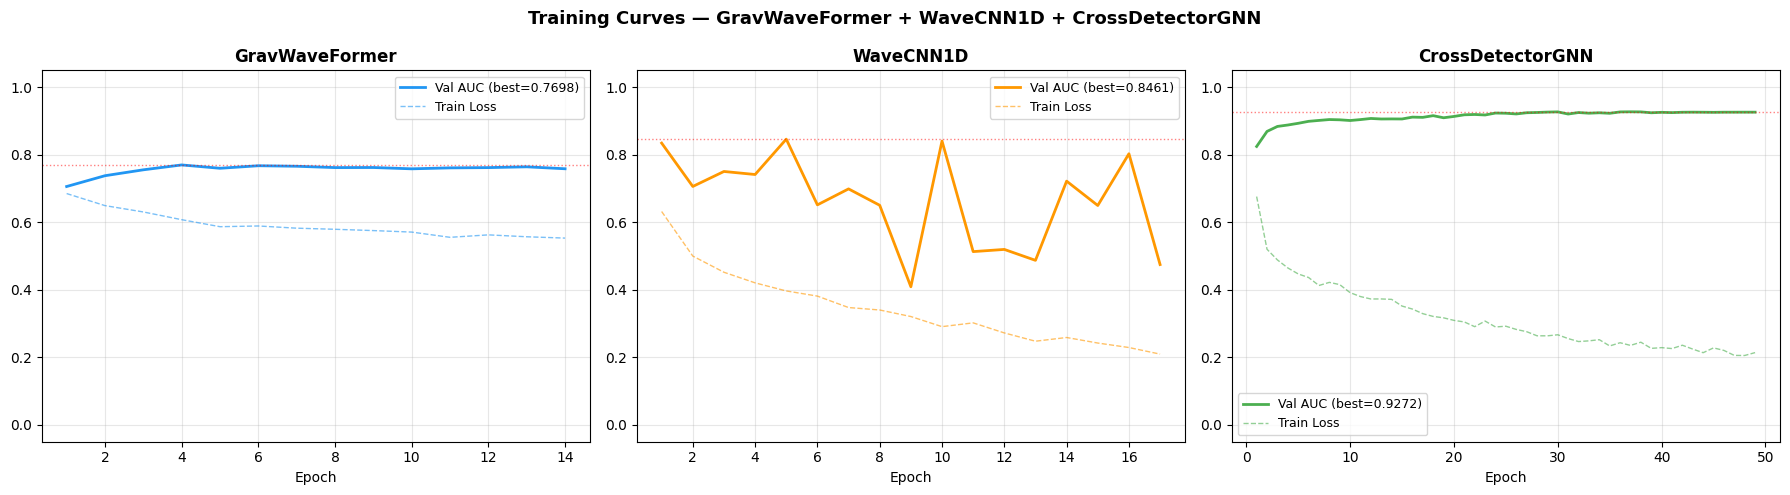

✓ Training curves saved


In [13]:
#   CELL 9 — TRAINING CURVES
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — GravWaveFormer + WaveCNN1D + CrossDetectorGNN',
             fontsize=13, fontweight='bold')

models_info = [
    ('GravWaveFormer',   hist_gw,  auc_gw,  axes[0], '#2196F3'),
    ('WaveCNN1D',        hist_1d,  auc_1d,  axes[1], '#FF9800'),
    ('CrossDetectorGNN', hist_gnn, auc_gnn, axes[2], '#4CAF50'),
]

for name, hist, best_auc_val, ax, color in models_info:
    epochs = range(1, len(hist['val_auc'])+1)
    ax.plot(epochs, hist['val_auc'],    color=color, lw=2,
            label=f'Val AUC (best={best_auc_val:.4f})')
    ax.plot(epochs, hist['train_loss'], color=color, lw=1,
            ls='--', alpha=0.6, label='Train Loss')
    ax.axhline(y=best_auc_val, color='red', ls=':', lw=1, alpha=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves_all_models.png', dpi=150)
plt.show()
print("✓ Training curves saved")


In [15]:
#   CELL 10 — SUMMARY
print()
print("=" * 60)
print("  NOTEBOOK 4 TRAINING COMPLETE")
print("=" * 60)
print()
print("  Model                Best Val AUC")
print("  " + "-" * 40)
print(f"  GravWaveFormer       {auc_gw:.4f}")
print(f"  WaveCNN1D            {auc_1d:.4f}")
print(f"  CrossDetectorGNN     {auc_gnn:.4f}")
print(f"  Ensemble MLP         {best_meta_auc:.4f}  ← should be highest")
print()
print("  Checkpoints saved:")
for name in ['gravwave', 'wave1d', 'gnn', 'ensemble_meta']:
    path = f'{CKPT_DIR}/best_{name}.pth'
    exists = '✓' if os.path.exists(path) else '✗'
    print(f"    {exists} {path}")
print()
print("  NEXT: Notebook_05_Evaluation")



  NOTEBOOK 4 TRAINING COMPLETE

  Model                Best Val AUC
  ----------------------------------------
  GravWaveFormer       0.7698
  WaveCNN1D            0.8461
  CrossDetectorGNN     0.9272
  Ensemble MLP         0.9417  ← should be highest

  Checkpoints saved:
    ✓ /content/drive/MyDrive/GravWaveFormer/checkpoints/best_gravwave.pth
    ✓ /content/drive/MyDrive/GravWaveFormer/checkpoints/best_wave1d.pth
    ✓ /content/drive/MyDrive/GravWaveFormer/checkpoints/best_gnn.pth
    ✓ /content/drive/MyDrive/GravWaveFormer/checkpoints/best_ensemble_meta.pth

  NEXT: Notebook_05_Evaluation
